# 06 — Error Analysis

Looks at where the LLM approaches succeed and fail, separately for the
**English** demonstration set (Notebook 04) and the **Korean** evaluation set
(Notebooks 05 / 05b). The framework follows Larooij & Graus (2026): split
samples into easy vs. hard by how much the methods agree, then look for
patterns that separate the groups. Ateş & Graus (2026) motivate reading
results without task-specific training data as informative even where they
fall below the supervised ceiling.

**Three questions:**
1. Across the LLM approaches, which samples do they disagree on?
2. Which samples do all approaches get right (easy) vs. all get wrong (hard)?
3. What linguistic or structural patterns separate easy from hard samples?

**Inputs:**
- `data_new/english_predictions.csv` — English, GPT-4o methods (Notebook 04)
- `korean_predictions_v2.csv` — Korean, GPT-4o methods (Notebook 05b)

Both sets share the same method family: Direct and CoT prompting across three
input conditions (sentence window, quote-to-quote, full article). NLI and the
few-shot variant are not part of the evaluation and are excluded here. Korean
quotes are shown with English translations, since the analyst does not read
Korean.

## 0. Setup

The two datasets carry the same six LLM prediction columns: Direct and CoT
prompting, each under the sentence-window (`sent`), quote-to-quote (`q2q`) and
full-article (`full`) input conditions. Cosine is a similarity baseline, not an
LLM, so it is excluded from the agreement analysis.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LLM_COLS  = ['pred_gpt_sent', 'pred_gpt_q2q', 'pred_gpt_full',
             'pred_cot_sent', 'pred_cot_q2q', 'pred_cot_full']
LLM_NAMES = ['Direct ctx', 'Direct q2q', 'Direct full',
             'CoT ctx', 'CoT q2q', 'CoT full']

# Korean stores the direct sentence-window and full columns without a suffix.
KO_RENAME = {
    'pred_gpt':      'pred_gpt_sent',
    'pred_cot':      'pred_cot_sent',
    'score_gpt':     'score_gpt_sent',
    'score_cot':     'score_cot_sent',
}

## 1. Load Data and Assign Groups

`add_groups` does the core bookkeeping for either dataset: count how many
methods vote contextomized, flag the unanimous cases, take the majority vote as
the ensemble prediction, and split every sample into one of three groups.

- **easy_correct** — all methods agree and the ensemble is right
- **easy_wrong** — all methods agree and the ensemble is wrong (the most
  diagnostic failures: every approach confidently misses the same case)
- **hard** — the methods are split

In [26]:
def add_groups(df, pred_cols):
    n = len(pred_cols)
    df = df.copy()
    df['n_votes'] = df[pred_cols].sum(axis=1)
    df['unanimous'] = df['n_votes'].isin([0, n])
    df['majority_pred'] = (df['n_votes'] >= n / 2).astype(int)
    df['easy_correct'] = df['unanimous'] & (df['majority_pred'] == df['label'])
    df['easy_wrong']   = df['unanimous'] & (df['majority_pred'] != df['label'])
    df['hard']         = ~df['unanimous']
    return df

In [27]:
en = pd.read_csv('data_new/english_predictions.csv')
ko = pd.read_csv('data/korean_predictions_v2.csv').rename(columns=KO_RENAME)

en['label'] = en['label'].astype(int)
ko['label'] = ko['label'].astype(int)

en = add_groups(en, LLM_COLS)
ko = add_groups(ko, LLM_COLS)

for name, df in [('English', en), ('Korean', ko)]:
    print(f"{name}: {len(df)} samples  |  "
          f"contextomized={int((df['label']==1).sum())}  modified={int((df['label']==0).sum())}")
    print("  group sizes:", df[['easy_correct', 'easy_wrong', 'hard']].sum().to_dict())
    print()

English: 100 samples  |  contextomized=10  modified=90
  group sizes: {'easy_correct': 23, 'easy_wrong': 9, 'hard': 68}

Korean: 1600 samples  |  contextomized=814  modified=786
  group sizes: {'easy_correct': 282, 'easy_wrong': 102, 'hard': 1216}



## 2. Vote Distribution

How often the methods land on each vote tally. A U-shape (mass at 0 and at the
maximum) means the methods mostly agree; mass in the middle means frequent
disagreement.

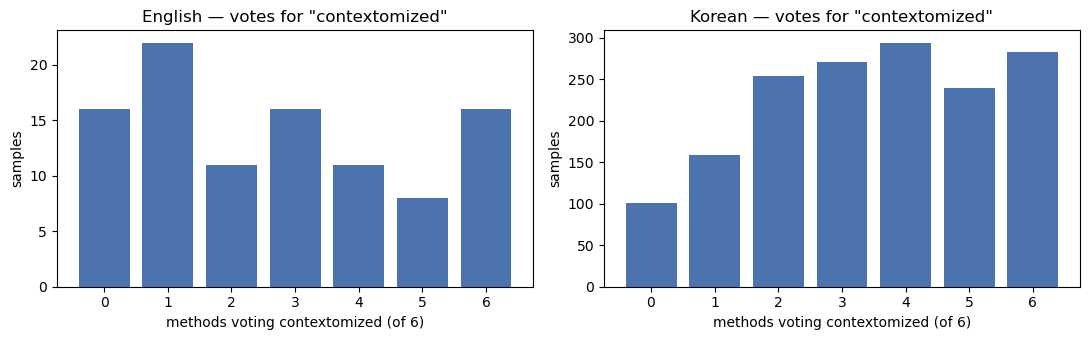

In [28]:
n_methods = len(LLM_COLS)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (name, df) in zip(axes, [('English', en), ('Korean', ko)]):
    counts = df['n_votes'].value_counts().reindex(range(n_methods + 1), fill_value=0).sort_index()
    ax.bar(counts.index, counts.values, color='#4C72B0')
    ax.set_title(f'{name} — votes for "contextomized"')
    ax.set_xlabel(f'methods voting contextomized (of {n_methods})')
    ax.set_ylabel('samples')
plt.tight_layout()
plt.savefig('figures/error_vote_distribution.png', dpi=150)
plt.show()

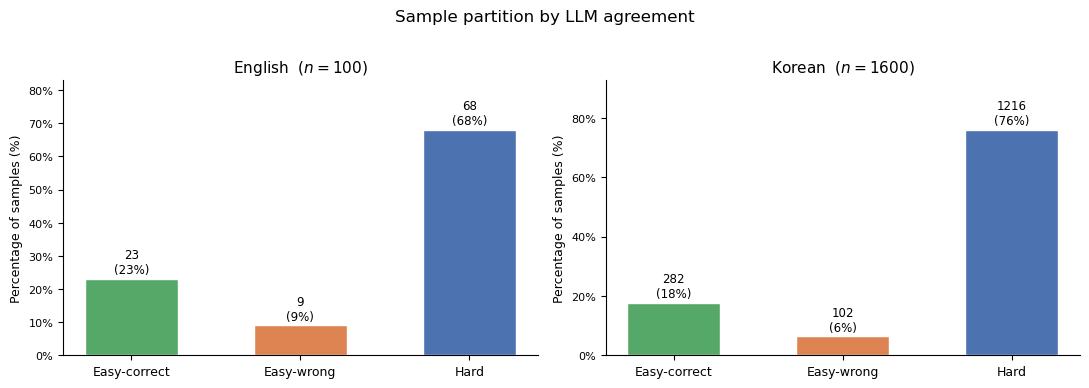

In [29]:
# Sample partition: easy-correct / easy-wrong / hard.
# Stacked percentage bars so English (n=100) and Korean (n=1600) sit on the
# same axis. Raw counts are annotated on each bar.
import matplotlib.ticker as mticker

groups = ['easy_correct', 'easy_wrong', 'hard']
LABELS = ['Easy-correct', 'Easy-wrong', 'Hard']
COLORS = ['#55A868', '#DD8452', '#4C72B0']

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)

for ax, (name, df) in zip(axes, [('English', en), ('Korean', ko)]):
    n = len(df)
    counts = {g: int(df[g].sum()) for g in groups}
    pcts = [100 * counts[g] / n for g in groups]
    bars = ax.bar(LABELS, pcts, color=COLORS, width=0.55, edgecolor='white')

    for bar, g, pct in zip(bars, groups, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f'{counts[g]}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=8.5)

    ax.set_title(f'{name}  ($n={n}$)', fontsize=11)
    ax.set_ylabel('Percentage of samples (%)', fontsize=9)
    ax.set_ylim(0, max(pcts) * 1.22)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Sample partition by LLM agreement', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/error_group_partition.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 3. Which Methods Behave Differently?

A pairwise agreement matrix per dataset: each cell is the fraction of samples on
which two methods make the same prediction. Methods with low mutual agreement
are picking up on different signals, which is useful for arguing that an input
condition (e.g. quote-to-quote) genuinely changes behaviour.

In [30]:
def agreement_matrix(df, pred_cols, names, title, savepath):
    n = len(pred_cols)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            mat[i, j] = (df[pred_cols[i]] == df[pred_cols[j]]).mean()
    fig, ax = plt.subplots(figsize=(0.9 * n + 2, 0.9 * n + 1))
    im = ax.imshow(mat, cmap='YlGnBu', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(names)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    plt.show()

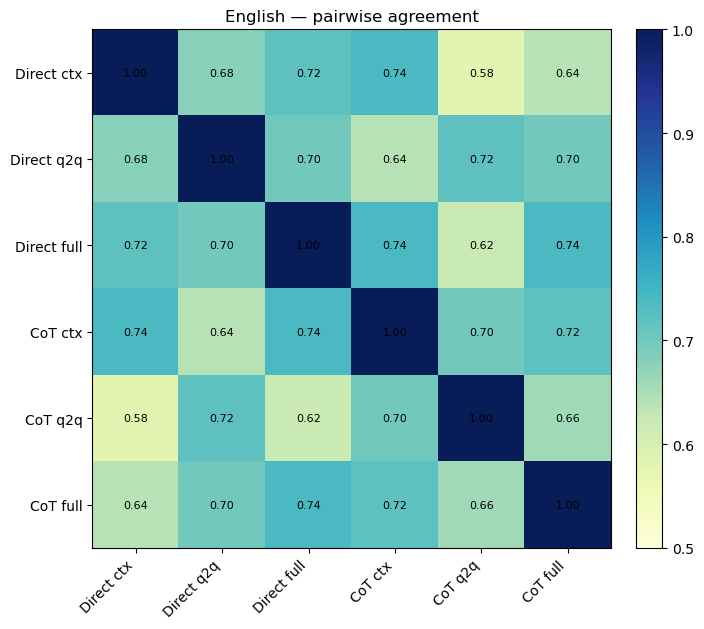

In [31]:
agreement_matrix(en, LLM_COLS, LLM_NAMES, 'English — pairwise agreement',
                 'figures/error_agreement_matrix_en.png')

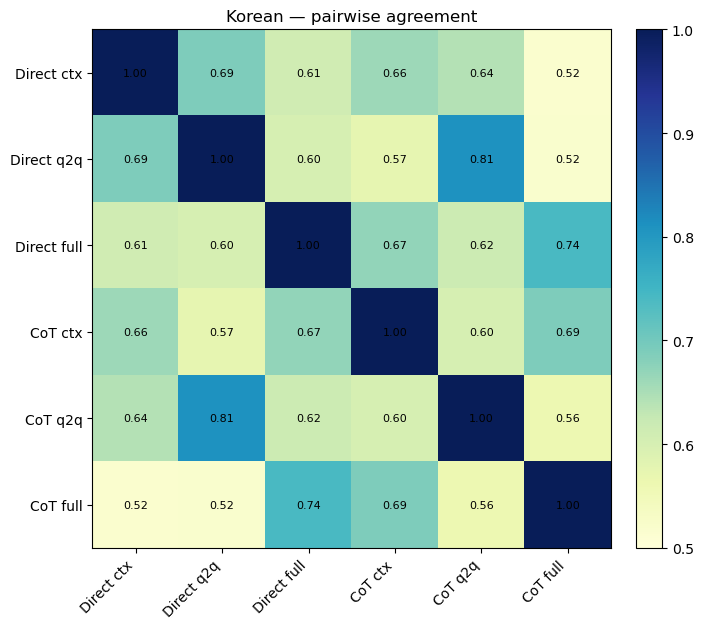

In [32]:
agreement_matrix(ko, LLM_COLS, LLM_NAMES, 'Korean — pairwise agreement',
                 'figures/error_agreement_matrix_ko.png')

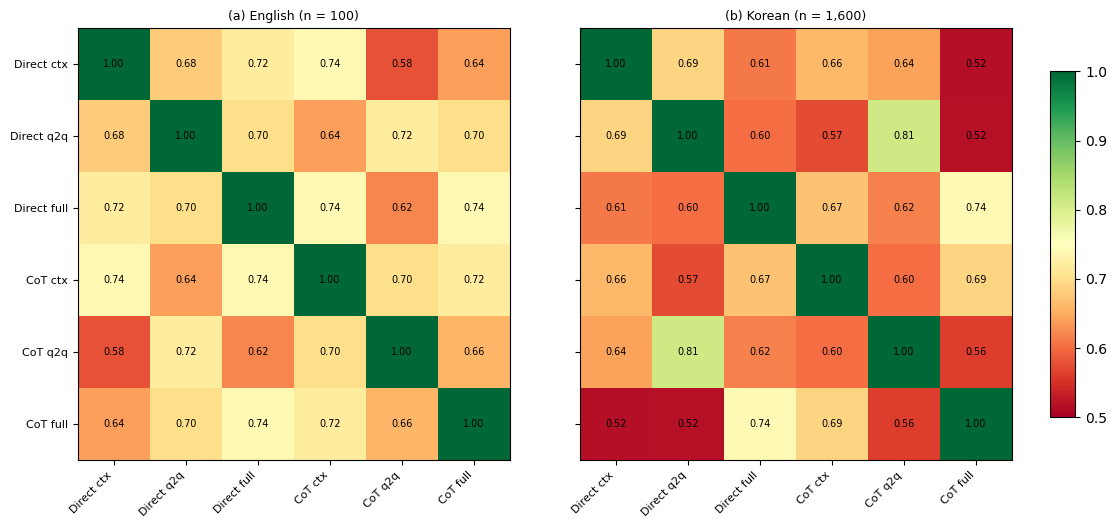

In [33]:
def agreement_heatmaps_combined(en, ko, cols, names,
                                cmap='RdYlGn',
                                savepath='figures/agreement_matrix_combined.pdf'):
    """English and Korean pairwise-agreement heatmaps side by side, square cells,
    shared colour scale."""
    def _compute_matrix(df):
        n = len(cols)
        mat = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                mat[i, j] = (df[cols[i]] == df[cols[j]]).mean()
        return mat

    mat_en = _compute_matrix(en)
    mat_ko = _compute_matrix(ko)
    n = len(cols)
    vmin, vmax = 0.5, 1.0

    cell_in, cbar_w, gap = 0.72, 0.25, 0.7
    lmargin, bmargin, tmargin, rmargin = 1.2, 1.4, 0.65, 0.9
    panel_w = cell_in * n
    panel_h = cell_in * n

    fig_w = lmargin + panel_w + gap + panel_w + gap + cbar_w + rmargin
    fig_h = tmargin + panel_h + bmargin
    fig = plt.figure(figsize=(fig_w, fig_h))

    def fi(x): return x / fig_w
    def fj(y): return y / fig_h

    ax_en = fig.add_axes([fi(lmargin), fj(bmargin), fi(panel_w), fj(panel_h)])
    ax_ko = fig.add_axes([fi(lmargin + panel_w + gap), fj(bmargin), fi(panel_w), fj(panel_h)])
    ax_cb = fig.add_axes([fi(lmargin + panel_w + gap + panel_w + gap * 0.55),
                          fj(bmargin + panel_h * 0.1), fi(cbar_w), fj(panel_h * 0.8)])

    im = None
    for ax, mat, title in [(ax_en, mat_en, '(a) English (n = 100)'),
                           (ax_ko, mat_ko, '(b) Korean (n = 1,600)')]:
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
        ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(n)); ax.set_yticklabels(names, fontsize=8)
        ax.set_title(title, fontsize=9, pad=6)
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=7)

    ax_ko.set_yticklabels([])
    fig.colorbar(im, cax=ax_cb)
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

agreement_heatmaps_combined(en, ko, LLM_COLS, LLM_NAMES)

## 4. Per-Method Accuracy on Easy vs. Hard

By construction every method scores ~1.0 on easy_correct and ~0.0 on
easy_wrong. The informative column is **hard**: which methods stay accurate when
the ensemble is split is the real differentiator.

In [34]:
def accuracy_by_group(df, pred_cols, names):
    rows = []
    for col, name in zip(pred_cols, names):
        row = {'method': name}
        for group in ['easy_correct', 'easy_wrong', 'hard']:
            sub = df[df[group]]
            row[group] = (sub[col] == sub['label']).mean() if len(sub) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('method').round(3)

In [35]:
print("English:")
print(accuracy_by_group(en, LLM_COLS, LLM_NAMES))
print("\nKorean:")
print(accuracy_by_group(ko, LLM_COLS, LLM_NAMES))

English:
             easy_correct  easy_wrong   hard
method                                      
Direct ctx            1.0         0.0  0.588
Direct q2q            1.0         0.0  0.676
Direct full           1.0         0.0  0.706
CoT ctx               1.0         0.0  0.559
CoT q2q               1.0         0.0  0.382
CoT full              1.0         0.0  0.471

Korean:
             easy_correct  easy_wrong   hard
method                                      
Direct ctx            1.0         0.0  0.493
Direct q2q            1.0         0.0  0.722
Direct full           1.0         0.0  0.498
CoT ctx               1.0         0.0  0.480
CoT q2q               1.0         0.0  0.666
CoT full              1.0         0.0  0.465


## 5. What Separates Easy From Hard Samples?

Following Larooij & Graus, we look for surface features that differ between
groups. Candidates here: quote-to-quote similarity between the headline quote
and its matched body quote (`best_quote_sim`), the sentence-window similarity
(`best_sim`), and simple length features. The expectation is that easy-correct
samples sit at the extremes of similarity while hard samples cluster in the
ambiguous middle.

In [36]:
def add_length_features(df):
    df = df.copy()
    df['quote_len'] = df['headline_quote'].fillna('').str.split().str.len()
    df['ctx_len'] = (
        df['prev_sentence'].fillna('') + ' ' +
        df['best_body_sentence'].fillna('') + ' ' +
        df['next_sentence'].fillna('')
    ).str.split().str.len()
    return df

def pattern_summary(df):
    candidates = ['best_quote_sim', 'best_sim', 'quote_len', 'ctx_len', 'label']
    cols = [c for c in candidates if c in df.columns]
    out = []
    for group in ['easy_correct', 'easy_wrong', 'hard']:
        sub = df[df[group]]
        means = sub[cols].mean()
        means['n'] = len(sub)
        means.name = group
        out.append(means)
    return pd.DataFrame(out).round(3)

In [37]:
en = add_length_features(en)
ko = add_length_features(ko)

print("English:")
print(pattern_summary(en))
print("\nKorean:")
print(pattern_summary(ko))

English:
              best_quote_sim  best_sim  quote_len  ctx_len  label     n
easy_correct           0.698     0.756      8.391   72.087  0.304  23.0
easy_wrong             0.528     0.537      5.333   77.111  0.000   9.0
hard                   0.786     0.703      7.603   76.956  0.044  68.0

Korean:
              best_quote_sim  best_sim  quote_len  ctx_len  label       n
easy_correct           0.584     0.546      3.940   52.514  0.691   282.0
easy_wrong             0.672     0.578      4.157   54.324  0.137   102.0
hard                   0.622     0.559      4.456   51.137  0.498  1216.0


/var/folders/_j/430fpj1s0sgbyv892y3mc0nm0000gn/T/ipykernel_6742/2822165059.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)
/var/folders/_j/430fpj1s0sgbyv892y3mc0nm0000gn/T/ipykernel_6742/2822165059.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)


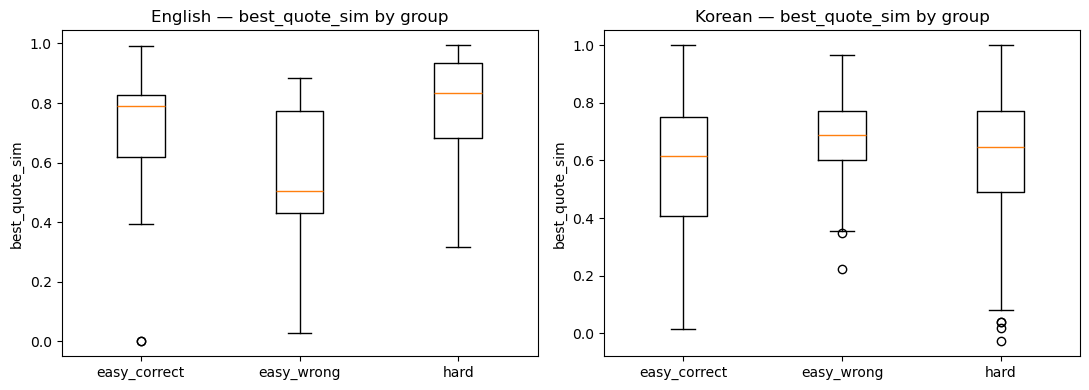

In [38]:
# Quote-to-quote similarity by group, side by side. easy-correct expected at the
# extremes, hard in the middle.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
groups = ['easy_correct', 'easy_wrong', 'hard']
for ax, (name, df) in zip(axes, [('English', en), ('Korean', ko)]):
    data = [df.loc[df[g], 'best_quote_sim'].dropna() for g in groups]
    ax.boxplot(data, labels=groups)
    ax.set_title(f'{name} — best_quote_sim by group')
    ax.set_ylabel('best_quote_sim')
plt.tight_layout()
plt.savefig('figures/error_sim_by_group.png', dpi=150)
plt.show()

## 6. Translation Helper (Korean → English)

So Korean cases are readable. Uses the keyless MyMemory API; if the environment
has no network it degrades to `[translation unavailable]` rather than crashing.
For heavier use, `deep-translator` (`pip install deep-translator`) is a sturdier
alternative.

In [39]:
import requests

def translate_ko(text, max_chars=400):
    text = str(text)[:max_chars]
    if not text.strip():
        return ''
    try:
        r = requests.get('https://api.mymemory.translated.net/get',
                         params={'q': text, 'langpair': 'ko|en'}, timeout=5)
        return r.json()['responseData']['translatedText']
    except Exception:
        return '[translation unavailable]'

## 7. Qualitative Inspection

The cases worth reading and quoting in the write-up: **unanimous errors** (every
method wrong) and the **most-split** hard cases. English is shown as-is; Korean
is shown with a translation underneath each field.

In [40]:
def show_cases(subset, n, title, translate=False):
    print(f"=== {title} (showing {min(n, len(subset))} of {len(subset)}) ===\n")
    for idx, row in subset.head(n).iterrows():
        quote   = str(row['headline_quote'])[:300]
        context = str(row['best_body_sentence'])[:300]
        article_id = row['article_id'] if 'article_id' in row else idx
        print(f"idx={idx}  article_id={article_id}  "
              f"label={int(row['label'])}  votes_contextomized={int(row['n_votes'])}")
        if translate:
            print(f"  QUOTE (KO):   {quote}")
            print(f"  QUOTE (EN):   {translate_ko(quote)}")
            print(f"  CONTEXT (KO): {context}")
            print(f"  CONTEXT (EN): {translate_ko(context)}")
        else:
            print(f"  QUOTE:   {quote}")
            print(f"  CONTEXT: {context}")
        print()

def most_split(df):
    h = df[df['hard']].copy()
    n = h['n_votes'].max() if len(h) else 0
    h['split_dist'] = (h['n_votes'] - (n + h['n_votes'].min()) / 2).abs() if len(h) else 0
    return h.sort_values('split_dist')

### 7a. English cases

In [41]:
show_cases(en[en['easy_wrong']], 8, 'ENGLISH — unanimous errors', translate=False)

=== ENGLISH — unanimous errors (showing 8 of 9) ===

idx=14  article_id=25  label=0  votes_contextomized=6
  QUOTE:   Evil exists, you just have to hang on.
  CONTEXT: We all struggle.

idx=32  article_id=421  label=0  votes_contextomized=6
  QUOTE:   nan
  CONTEXT: "Your co-operation (with police) is a matter of some importance," he said.

idx=46  article_id=810  label=0  votes_contextomized=6
  QUOTE:   Young people express themselves here
  CONTEXT: Wild Geese: ‘Young people express themselves here’ Martin McKenna, country manager of Holidayguru website, Dortmund Martin McKenna: “I think we sell ourselves short in Ireland.

idx=51  article_id=926  label=0  votes_contextomized=6
  QUOTE:   not right thing to do
  CONTEXT: "I do think that building a third runway slap bang in the middle of the western suburbs of the greatest city on Earth is not the right thing to do," Johnson said.

idx=74  article_id=1571  label=0  votes_contextomized=6
  QUOTE:   Russian Propaganda Fake News
  CONT

In [42]:
show_cases(most_split(en), 5, 'ENGLISH — most-split hard cases', translate=False)

=== ENGLISH — most-split hard cases (showing 5 of 68) ===

idx=64  article_id=1263  label=0  votes_contextomized=3
  QUOTE:   Meningococcal, you hit my son like a wrecking ball
  CONTEXT: You hit my son yesterday like a wrecking ball but he came straight back at you like a d11 bulldozer," Mr Roberts wrote on Facebook on Friday night.

idx=79  article_id=1639  label=0  votes_contextomized=3
  QUOTE:   If these services end my boys will for certain die
  CONTEXT: “If these services end then my boys will for certain die once they become ill,” said Wiles.

idx=35  article_id=446  label=0  votes_contextomized=3
  QUOTE:   can still hit 25 goals this term
  CONTEXT: But former Hibs hitman McManus, who was at Stark’s Park last weekend to see Cummings fire a blank yet again in a no-scoring draw, insists the 21-year-old is still capable of claiming 25 Championship goals like he did last season.

idx=76  article_id=1618  label=0  votes_contextomized=3
  QUOTE:   Many scientists are afraid to hur

In [43]:
# ── representative cases for the thesis table ──────────────────────────────
# One easy-correct (all methods right), one easy-wrong (all methods wrong),
# two hard (methods evenly split 3/3).

def show_cases_table(subset, n, title):
    """Print cases in a compact format suitable for selecting thesis examples."""
    print(f"\n=== {title} (showing {min(n, len(subset))} of {len(subset)}) ===\n")
    for idx, row in subset.head(n).iterrows():
        quote   = str(row['headline_quote'])[:120]
        context = str(row['best_body_sentence'])[:200]
        votes   = int(row['n_votes'])
        label   = int(row['label'])
        pred    = int(row['majority_pred'])
        correct = 'CORRECT' if pred == label else 'WRONG'
        print(f"  idx={idx}  article_id={row['article_id']}  label={'C' if label==1 else 'M'}"
              f"  pred={'C' if pred==1 else 'M'}  votes_ctx={votes}  [{correct}]")
        print(f"  QUOTE:   {quote}")
        print(f"  CONTEXT: {context}")
        print()

# Easy-correct: separate contextomised (all methods right, label=1)
# and modified (all methods right, label=0)
ec_ctx  = en[en['easy_correct'] & (en['label'] == 1)]
ec_mod  = en[en['easy_correct'] & (en['label'] == 0)]

show_cases_table(ec_ctx,  5, 'ENGLISH — easy-correct CONTEXTOMISED (all 6 right)')
show_cases_table(ec_mod,  5, 'ENGLISH — easy-correct MODIFIED (all 6 right)')
show_cases_table(en[en['easy_wrong']], 8, 'ENGLISH — easy-wrong (all 6 wrong)')
show_cases_table(most_split(en),       5, 'ENGLISH — most-split hard cases')


=== ENGLISH — easy-correct CONTEXTOMISED (all 6 right) (showing 5 of 7) ===

  idx=0  article_id=967  label=C  pred=C  votes_ctx=6  [CORRECT]
  QUOTE:   We can sell anything, from your gumboots to your farm
  CONTEXT: “They can sell almost anything a farmer needs, from livestock, implements and vehicles to the farm itself,” says one of their satisfied customers.

  idx=1  article_id=1124  label=C  pred=C  votes_ctx=6  [CORRECT]
  QUOTE:   wanted to fire candidates based on their looks
  CONTEXT: To say that candidates are chosen purely for their looks or single lines on their CV is not true.” Reuse content

  idx=3  article_id=1326  label=C  pred=C  votes_ctx=6  [CORRECT]
  QUOTE:   most dangerous president of all time
  CONTEXT: I think he could be one of the most dangerous presidents to ever come into the Oval Office.

  idx=5  article_id=1103  label=C  pred=C  votes_ctx=6  [CORRECT]
  QUOTE:   I thought they would be safe
  CONTEXT: “I felt they would be as safe with him as they wo

### 7b. Korean cases (with translation)

In [44]:
show_cases(ko[ko['easy_wrong']], 8, 'KOREAN — unanimous errors', translate=True)

=== KOREAN — unanimous errors (showing 8 of 102) ===

idx=7  article_id=7  label=0  votes_contextomized=6
  QUOTE (KO):   ['평범하게 살기 싫어서 돈이다']
  QUOTE (EN):   ['Money because I don't want to live a normal life']
  CONTEXT (KO): ☞ [정현영의 벌어야 사는 사람들②-2] "돈 없이도 행복하다는 말은 거짓이다" ☞ [정현영의 벌어야 사는 사람들②-2] "돈 없이도 행복하다는 말은 거짓이다" 정현영 한경닷컴 기자 jhy@hankyung.com
  CONTEXT (EN): ☞ [People who buy money without Jeong Hyun-young ② -2] "It is a lie to say that you are happy without money" ☞ [People who buy money without Jeong Hyun-young ② -2] "It is a lie to say that you are happy without money" Jeong Hyun-young Hankyung.com reporter jhy@hankyung.com

idx=40  article_id=40  label=0  votes_contextomized=6
  QUOTE (KO):   ['외인 수급 中으로 몰려']
  QUOTE (EN):   ['They flock to the supply and demand of foreigners']
  CONTEXT (KO): 장효원기자 specialjhw@inews24.com 장효원기자 장효원기자
  CONTEXT (EN): Jang Hyo Atomic Journalist specialjhw@inews24.com Jang Hyo Atomic Journalist Jang Hyo Atomic Journalist

idx=51  article_id=51  label

In [45]:
show_cases(most_split(ko), 5, 'KOREAN — most-split hard cases', translate=True)

=== KOREAN — most-split hard cases (showing 5 of 1216) ===

idx=811  article_id=811  label=1  votes_contextomized=3
  QUOTE (KO):   ['도요타, 집단소송으로 3조원 물어줘야 할지도']
  QUOTE (EN):   ['Toyota, you may have to ask 3 trillion won for a class action lawsuit']
  CONTEXT (KO): 노스이스턴대학의 법과대학원 교수인 팀 하워드는 리콜 사태로 경제적 손실을 입었다고 주장하는 도요타 차량 보유자가 600만명에 달할 수 있으며 집단소송의 결과로 이들에게 1인당 최소 500달러의 보상금을 지급해야 한다면 도요타는 이 건으로만 30억달러 이상의 손실을 떠안게 될 것이라고 분석했다.
  CONTEXT (EN): Tim Howard, a professor at Northeastern University's Graduate School of Law, analyzed that there could be as many as six million Toyota vehicle holders claiming to have suffered economic losses due to the recall, and that if at least $500 per person had to be compensated as a result of the class action, Toyota would lose more than $3 billion in losses alone.

idx=787  article_id=787  label=1  votes_contextomized=3
  QUOTE (KO):   ['김장 절임배추 사 쓴다']
  QUOTE (EN):   ['I use kimjang pickled cabbage']
  CONTEXT (KO): 그만큼 요즈음 주부들이 김장 재료를 구매할 때 '편의성'을 중요

## 8. Save Annotated Predictions

Write the per-sample group flags for both datasets so the patterns can be
referenced directly in the write-up.

In [46]:
def save_annotated(df, path):
    cols = ['headline_quote', 'best_body_sentence', 'best_body_quote', 'label',
            'best_quote_sim', 'best_sim', 'quote_len', 'ctx_len', 'n_votes',
            'majority_pred', 'easy_correct', 'easy_wrong', 'hard']
    cols = [c for c in cols if c in df.columns]
    df[cols].to_csv(path, index=False)
    print('Saved:', path)

save_annotated(en, 'data_new/english_error_analysis.csv')
save_annotated(ko, 'data_new/korean_error_analysis.csv')

Saved: data_new/english_error_analysis.csv
Saved: data_new/korean_error_analysis.csv


In [47]:
# Short-context check on the unanimous Korean errors: how many have a very
# short matched body quote, which is the retrieval-failure pattern.
ko_wrong = ko[ko['easy_wrong']].copy()
ko_wrong['ctx_words'] = ko_wrong['best_body_quote'].fillna('').str.split().str.len()

print(f"easy_wrong with body quote < 10 words: {(ko_wrong['ctx_words'] < 10).sum()} / {len(ko_wrong)}")
print(f"easy_wrong with body quote < 5 words:  {(ko_wrong['ctx_words'] < 5).sum()} / {len(ko_wrong)}")
print()
print(ko_wrong[ko_wrong['ctx_words'] < 10][['headline_quote', 'best_body_quote', 'label']].to_string())

easy_wrong with body quote < 10 words: 27 / 102
easy_wrong with body quote < 5 words:  5 / 102

                          headline_quote                            best_body_quote  label
109                        ['전립선비대증 때문']                              소변과 관련한 증상 때문      0
139                          ['정신이 없어요']           하루종일 걸려오는 전화 때문에 정신을 못 차릴 지경입니다       0
158                         ['산은에 안팔겠다']            요구 조건을 들어주지 않으면 대우건설 지분을 팔지 않겠다      0
317                ['美 실업률 걸림돌..완만한 성장']                     미국 경제 성장세를 방해하는 요소가 많다      0
373                 ['경제자유구역내 외국기관 풀어야']         투자를 위해 경제자유구역내 외국 교육기관 설립의 길을 터 달라      0
532            ['금값 2,000달러까지…금ㆍ은 투자해라']           앞으로 10년 안에 금값이 온스당 2 000달러에 이를 것      0
598                ['통행료 올리지 못해 부채 늘었다']             요금 인상이 이뤄지지 않는 한 후세에 넘길 수밖에 없다      0
664                         ['미국호텔에 출몰']                        건강한 모습으로 미국호텔에 출몰한다      0
676                         ['나이 많은 노인']                               나이많은 노인은 안맞죠  